<a href="https://colab.research.google.com/github/updp16/Research_Appendices/blob/main/Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import rasterio
import numpy as np

# Load the exported GeoTIFF
img_path = '/content/drive/MyDrive/GEE_exports/S2_estuary_water.tif'

with rasterio.open(img_path) as src:
    bands = src.read().astype('float32')  # shape: (10, height, width)
    profile = src.profile                 # stores CRS, transform etc.
    nodata = src.nodata

print(f"Image shape: {bands.shape}")
print(f"Bands: {src.count}, Height: {src.height}, Width: {src.width}")

Image shape: (10, 1184, 1514)
Bands: 10, Height: 1184, Width: 1514


In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv(r"https://raw.githubusercontent.com/updp16/research/refs/heads/main/Features_Shell_point.csv")

selected_features = ['ND_B5_B3', 'ND_B5_B4', 'ND_B4_B3', 'RATIO_B7_B3']

X = df[selected_features]
y = df['Actual']

X = df[selected_features]
y = df['Actual']

# Clean data
X = X.replace([np.inf, -np.inf], np.nan)
data = pd.concat([X, y], axis=1).dropna()

X = data[selected_features]
y = data['Actual']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [ ]:
import numpy as np
import pandas as pd

model = rf
# Band order must match your GEE export band order
band_names = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']

n_bands, h, w = bands.shape
pixels = bands.reshape(n_bands, -1).T   # (n_pixels, 10)

# Put into DataFrame with band names
df = pd.DataFrame(pixels, columns=band_names)

eps = 1e-10  # avoid division by zero

# Compute exactly the 4 features your model expects
df['ND_B5_B3']   = (df['B5'] - df['B3']) / (df['B5'] + df['B3'] + eps)
df['ND_B5_B4']   = (df['B5'] - df['B4']) / (df['B5'] + df['B4'] + eps)
df['ND_B4_B3']   = (df['B4'] - df['B3']) / (df['B4'] + df['B3'] + eps)
df['RATIO_B7_B3'] = df['B7'] / (df['B3'] + eps)

# Select only these 4 features in correct order
selected_features = ['ND_B5_B3', 'ND_B5_B4', 'ND_B4_B3', 'RATIO_B7_B3']
df_selected = df[selected_features]

# Valid water pixel mask
valid_mask = ~df_selected.isna().any(axis=1) & ~(bands.reshape(n_bands, -1).T == 0).all(axis=1)

# Predict
predictions = np.full(h * w, np.nan)
predictions[valid_mask] = model.predict(df_selected[valid_mask])

# Reshape back to image
pred_map = predictions.reshape(h, w)
print("Done! Map shape:", pred_map.shape)
print(f"Value range: {np.nanmin(pred_map):.2f} — {np.nanmax(pred_map):.2f}")

Done! Map shape: (1184, 1514)
Value range: 0.73 — 5.18


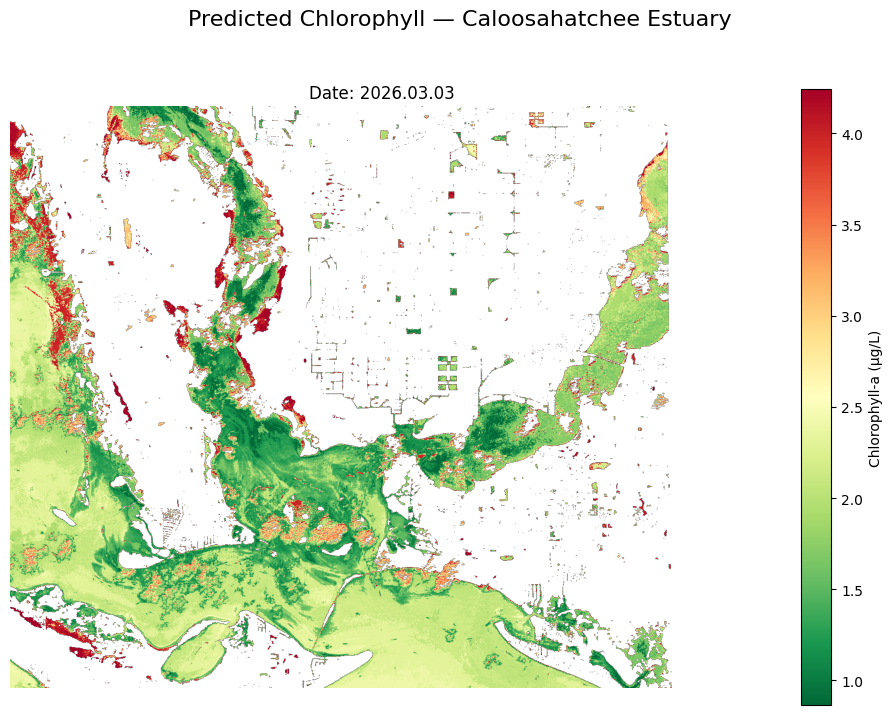

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(12, 8))
img = plt.imshow(pred_map, cmap='RdYlGn_r',
                  vmin=np.nanpercentile(pred_map, 2),
                  vmax=np.nanpercentile(pred_map, 98))
plt.colorbar(img, label='Chlorophyll-a (µg/L)')
plt.suptitle('Predicted Chlorophyll — Caloosahatchee Estuary', fontsize=16)
plt.title('Date: 2026.03.03', fontsize=12)
plt.axis('off')
plt.savefig('/content/drive/MyDrive/Chl-a_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
out_profile = profile.copy()
out_profile.update(count=1, dtype='float32', nodata=np.nan)

with rasterio.open('/content/drive/MyDrive/Chl-a_map.tif', 'w', **out_profile) as dst:
    dst.write(pred_map.astype('float32'), 1)

print("Saved!")

Saved!
